<a href="https://colab.research.google.com/github/shiva123786/FUTURE_DS_03/blob/master/Student%20FeedBack%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd

In [13]:
data=pd.read_excel("/content/Student_Satisfaction_Survey.xls")
data1=pd.read_excel("/content/student_feedback.xls")

In [14]:
data

,SN,Total Feedback Given,Total Configured,Questions,Weightage 1,Weightage 2,Weightage 3,Weightage 4,Weightage 5,Average/ Percentage,Course Name,Basic Course
0,1,1,12,How much of the syllabus was covered in the cl...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
1,2,1,12,How well did the teachers prepare for the clas...,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
2,3,1,12,How well were the teachers able to communicate?,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
3,4,1,12,The teacher’s approach to teaching can best be...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
4,5,1,12,Fairness of the internal evaluation process by...,0,0,0,1,0,4.00 / 80.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
...,...,...,...,...,...,...,...,...,...,...,...,...
575,16,9,170,The institute/ teachers use student-centric me...,1,0,0,2,6,4.33 / 86.67,TYBSC,BACHELOR OF SCIENCE
576,17,9,170,Teachers encourage you to participate in extra...,0,0,0,3,6,4.67 / 93.33,TYBSC,BACHELOR OF SCIENCE
577,18,9,170,Efforts are made by the institute/ teachers to...,0,0,1,2,6,4.56 / 91.11,TYBSC,BACHELOR OF SCIENCE
578,19,9,170,What percentage of teachers use ICT tools such...,0,0,1,3,5,4.44 / 88.89,TYBSC,BACHELOR OF SCIENCE


In [15]:
data1

,Unnamed: 0,Student ID,Well versed with the subject,Explains concepts in an understandable way,Use of presentations,Degree of difficulty of assignments,Solves doubts willingly,Structuring of the course,Provides support for students going above and beyond,Course recommendation based on relevance
0,0,340,5,2,7,6,9,2,1,8
1,1,253,6,5,8,6,2,1,2,9
2,2,680,7,7,6,5,4,2,3,1
3,3,806,9,6,7,1,5,9,4,6
4,4,632,8,10,8,4,6,6,9,9
...,...,...,...,...,...,...,...,...,...,...
996,996,55,8,7,6,2,5,7,7,9
997,997,913,5,5,6,5,6,7,6,1
998,998,199,9,5,8,3,8,1,1,2
999,999,539,10,2,7,4,3,4,10,1


In [16]:
df=pd.concat([data,data1],axis=1)

In [17]:
df.fillna(0,inplace=True)

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

id_col = 'Student ID'
non_numeric_cols = ['Questions', 'Average/ Percentage', 'Course Name', 'Basic Course']
rating_cols = [c for c in df.columns if c not in ['Unnamed: 0', id_col] + non_numeric_cols]
# Convert columns in rating_cols to numeric, coercing errors to NaN
for col in rating_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
# Drop columns with all NaN values after conversion if any
df.dropna(axis=1, how='all', inplace=True)
# Update rating_cols to reflect columns that are now numeric
rating_cols = [c for c in df.columns if c not in ['Unnamed: 0', id_col] + non_numeric_cols]

In [19]:
avg_scores = df[rating_cols].mean().sort_values(ascending=False)
print('Average scores:\n', avg_scores)

Average scores:
 Total Configured                                        53.606394
Total Feedback Given                                     8.291708
Well versed with the subject                             7.497502
SN                                                       6.083916
Explains concepts in an understandable way               6.081918
Use of presentations                                     5.942058
Provides support for students going above and beyond     5.662338
Structuring of the course                                5.636364
Course recommendation based on relevance                 5.598402
Solves doubts willingly                                  5.474525
Degree of difficulty of assignments                      5.430569
Weightage 4                                              2.945055
Weightage 5                                              2.882118
Weightage 3                                              1.470529
Weightage 2                                              0.

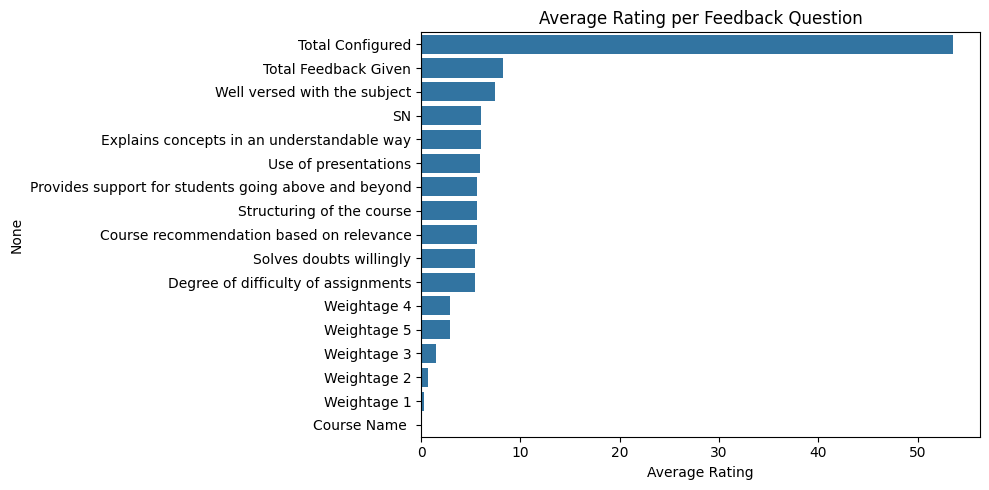

In [20]:
# Plot average ratings
plt.figure(figsize=(10,5))
sns.barplot(x=avg_scores.values, y=avg_scores.index)
plt.title('Average Rating per Feedback Question')
plt.xlabel('Average Rating')
plt.tight_layout()
plt.show()

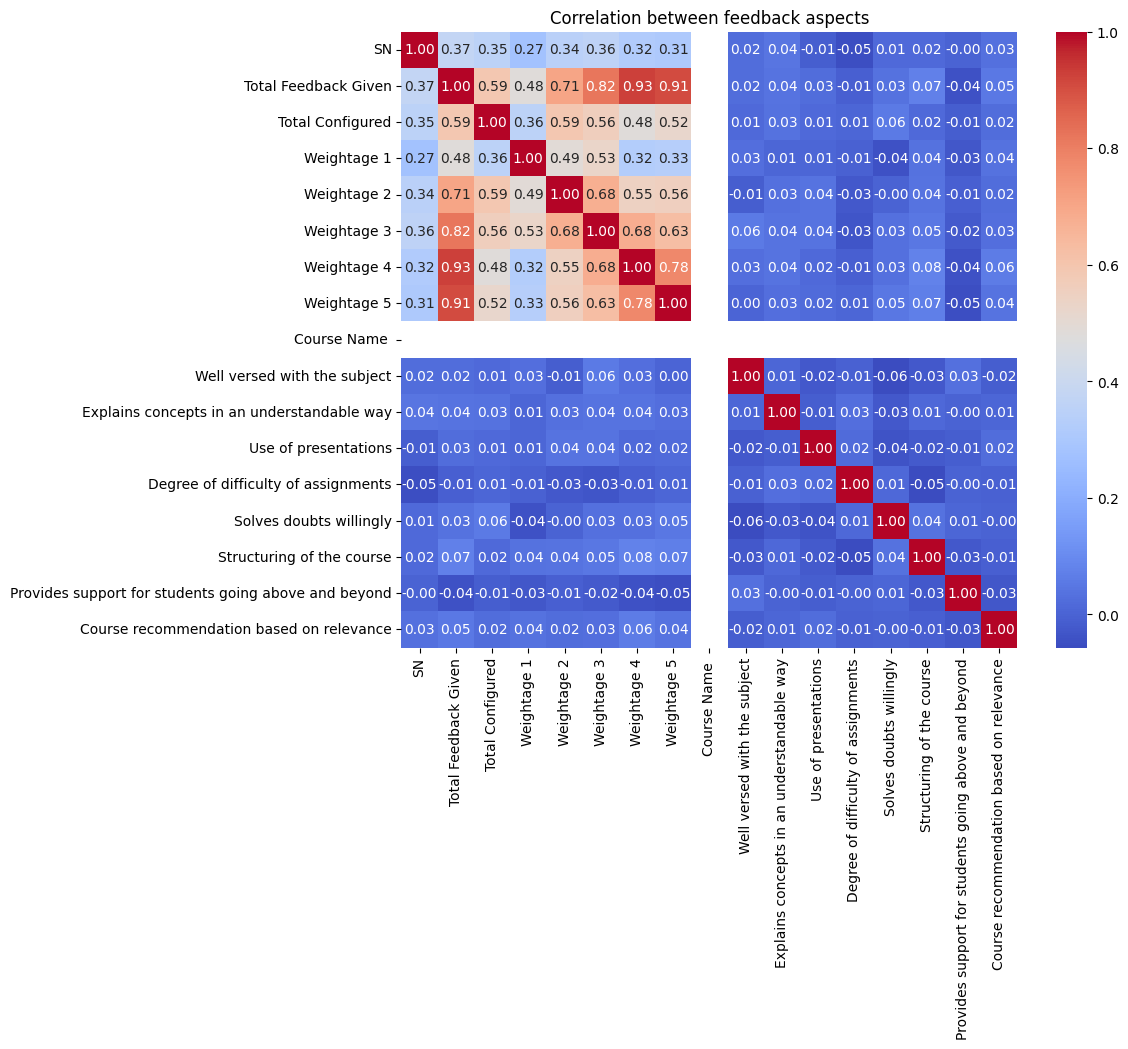

In [21]:
# Correlation heatmap
plt.figure(figsize=(10,8))
corr = df[rating_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation between feedback aspects')
plt.show()

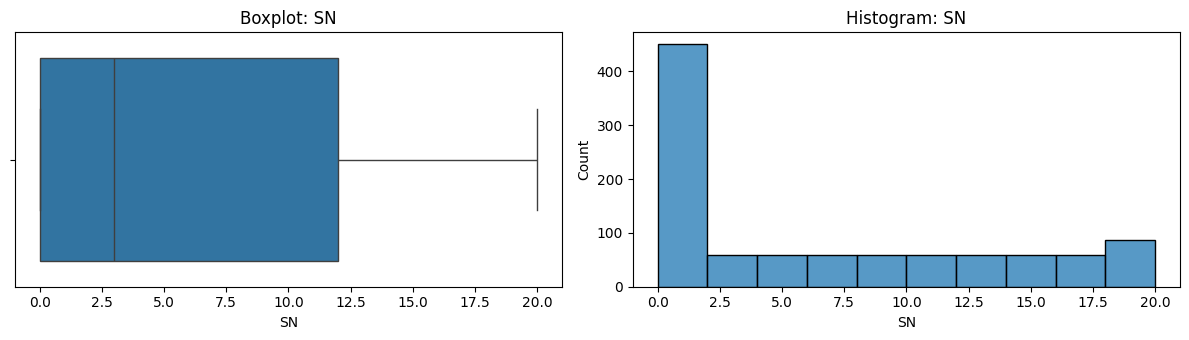

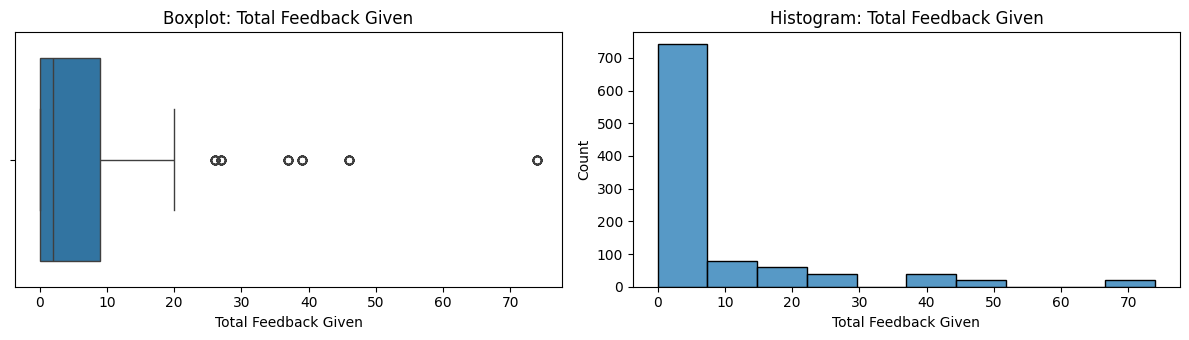

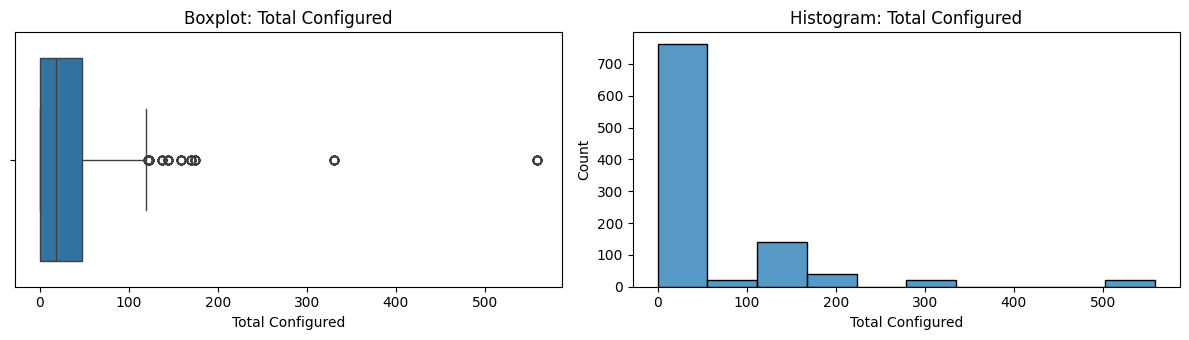

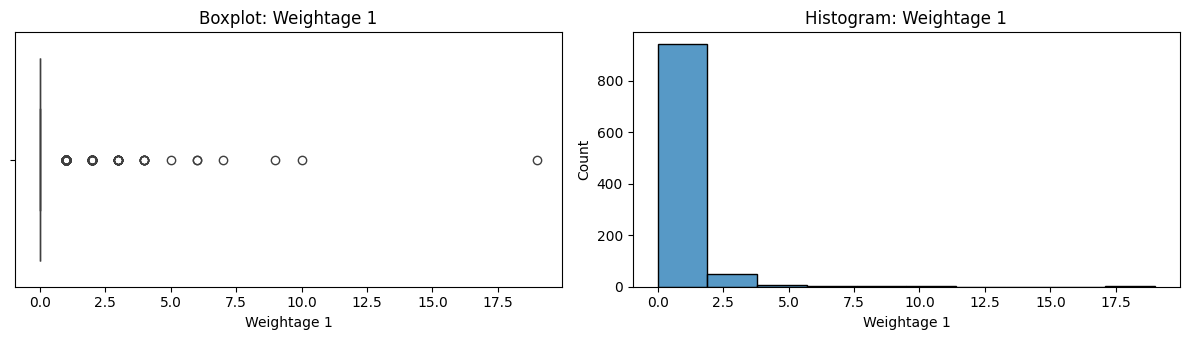

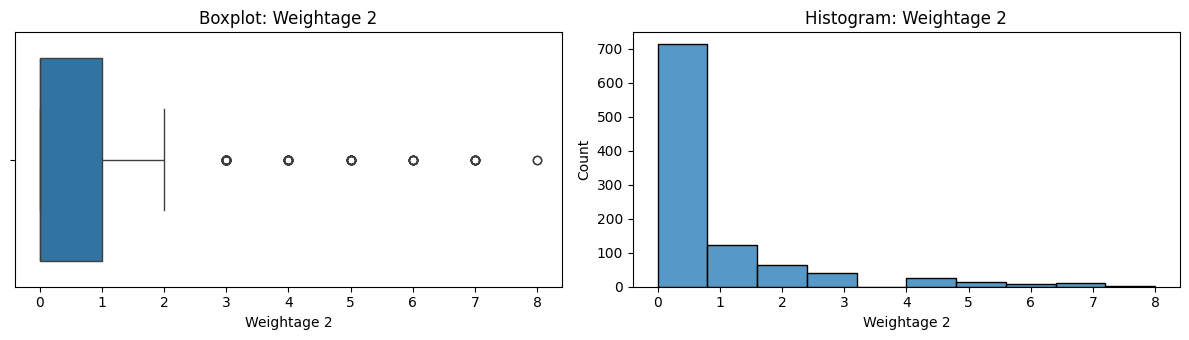

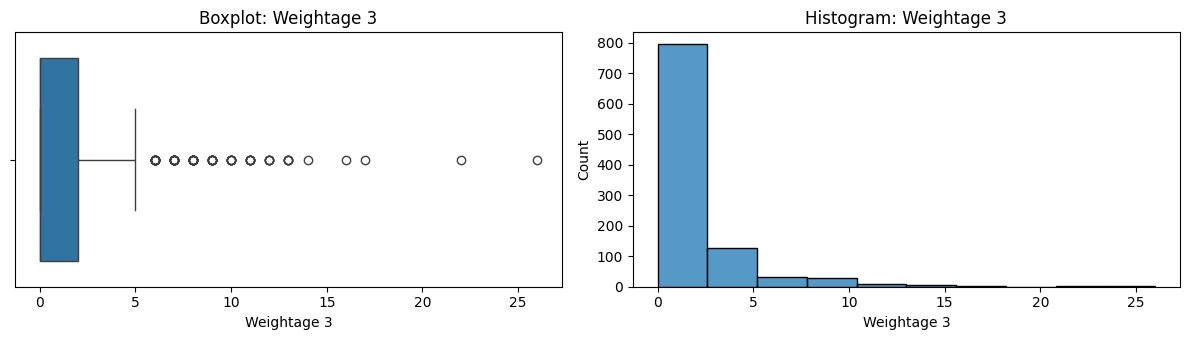

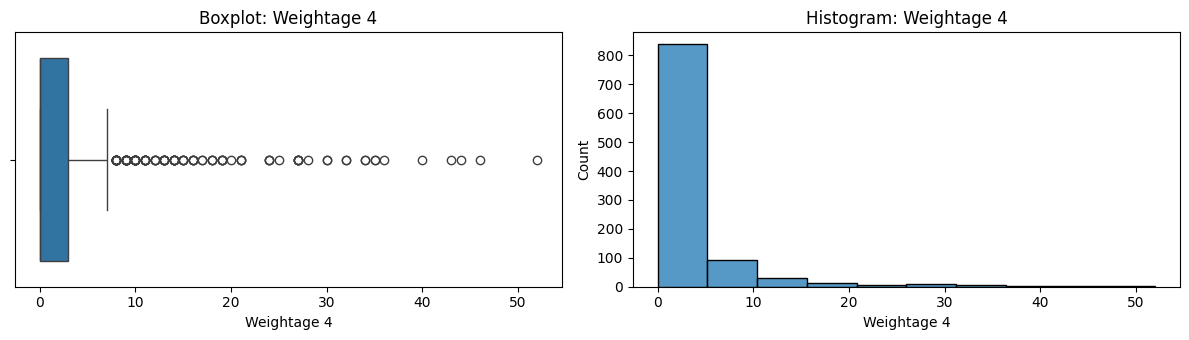

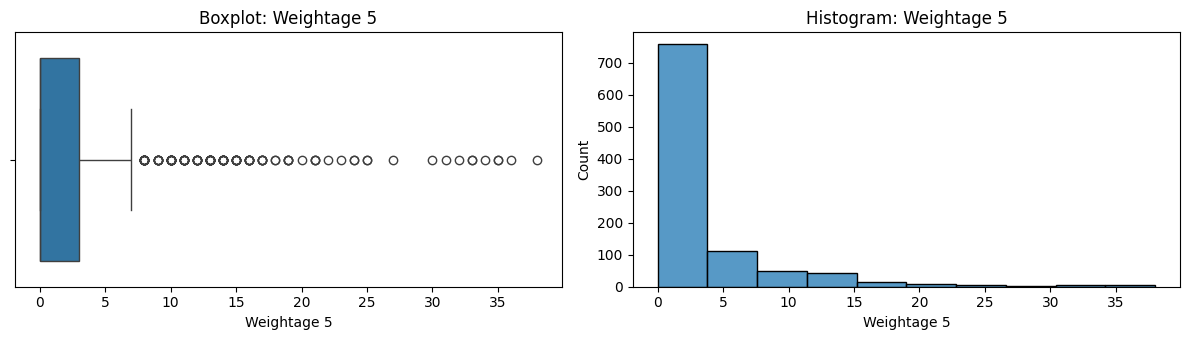

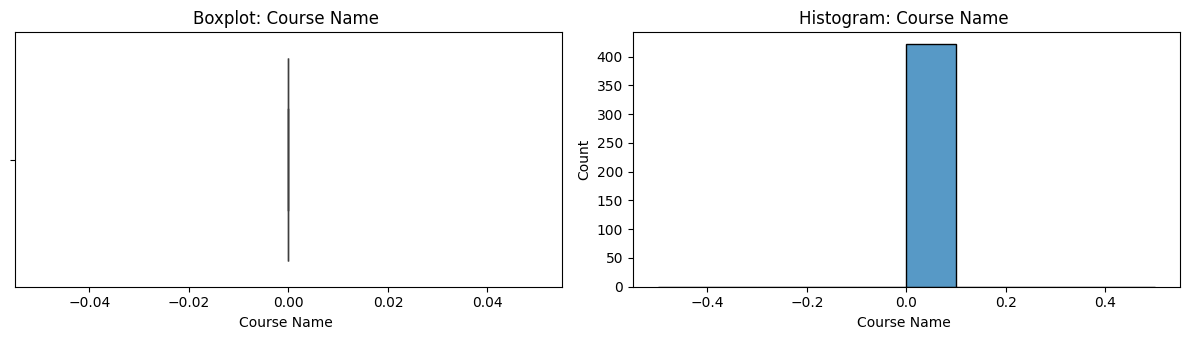

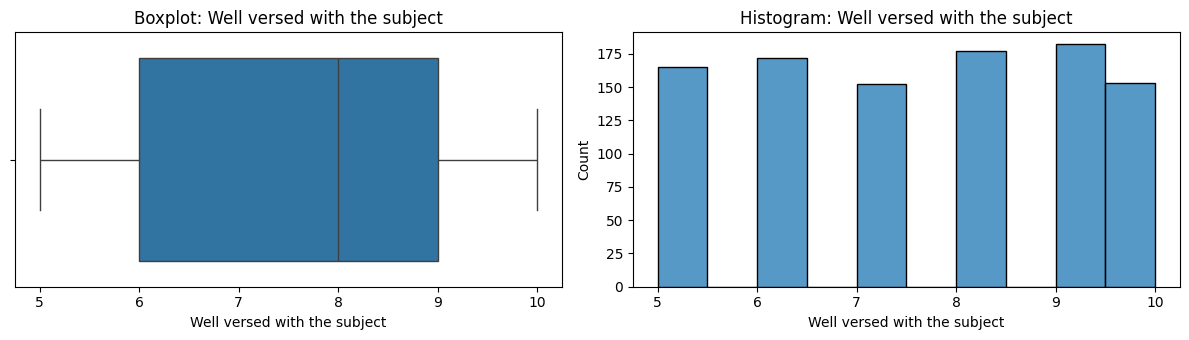

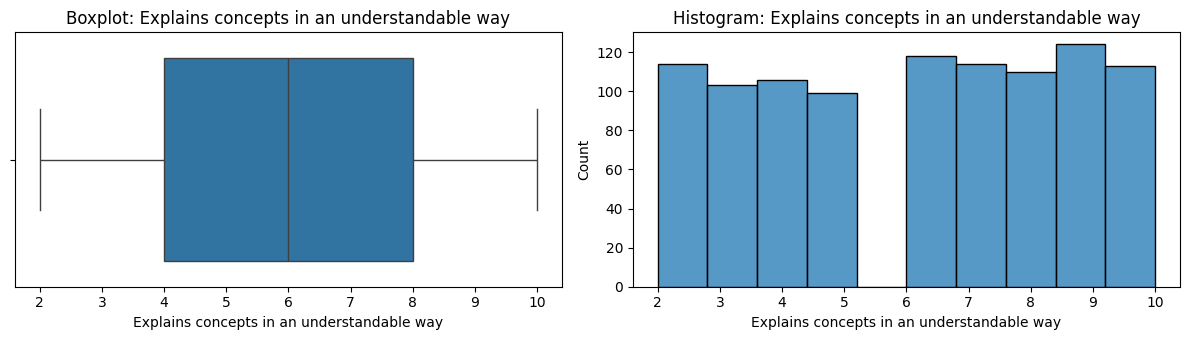

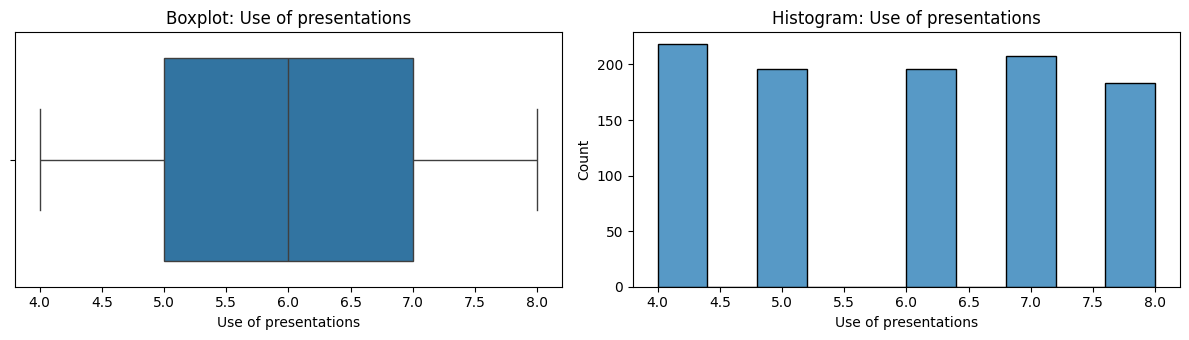

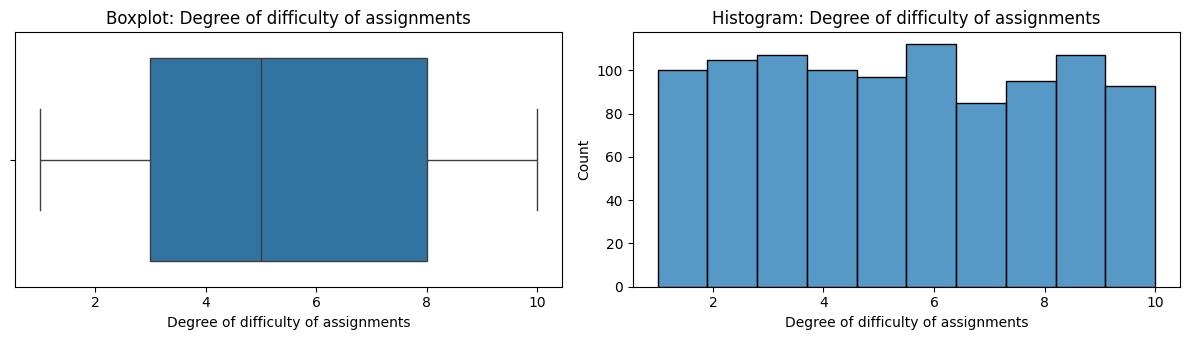

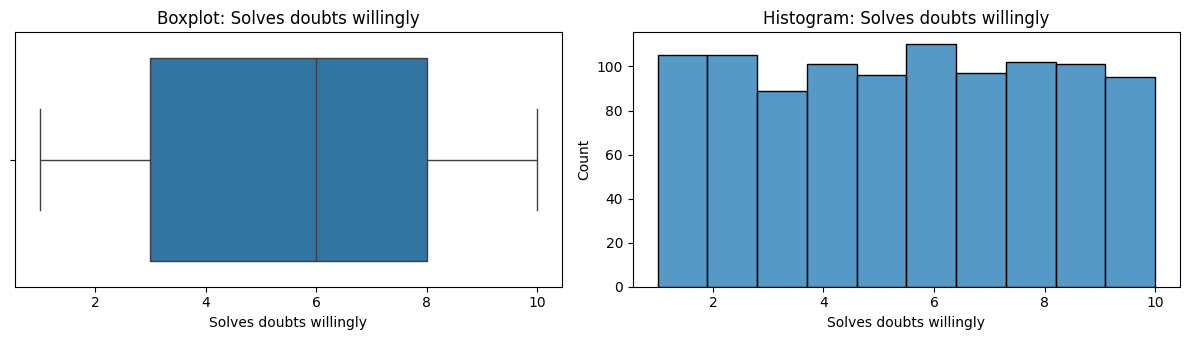

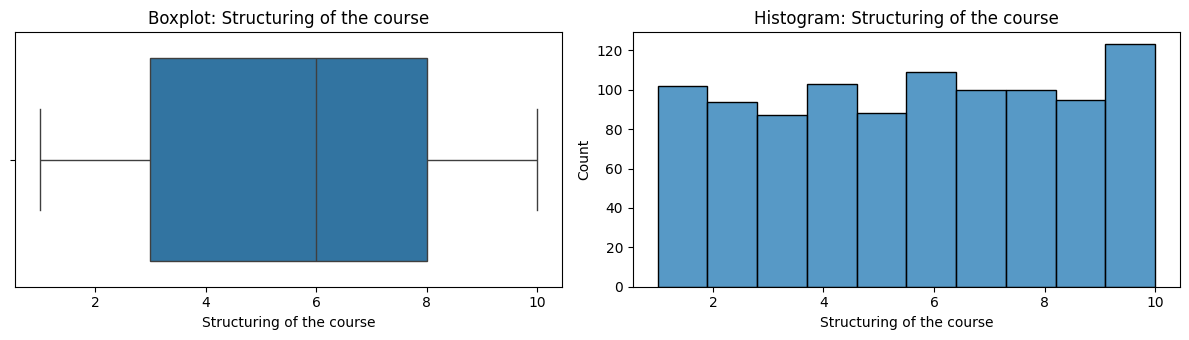

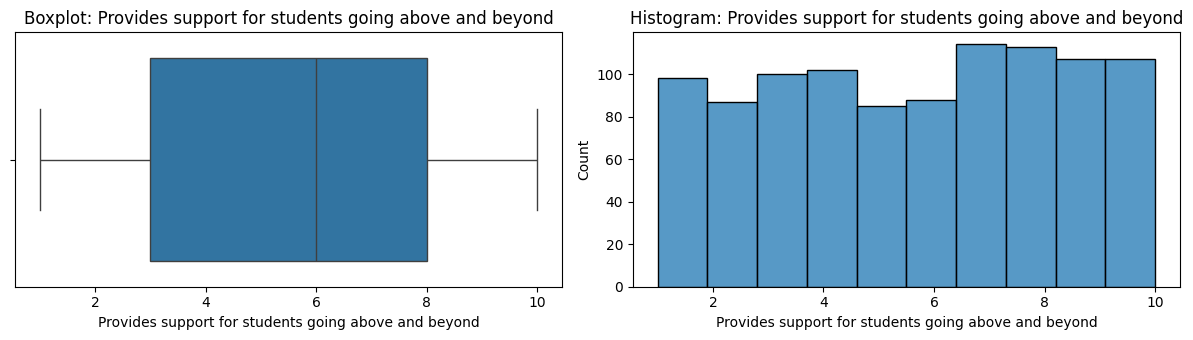

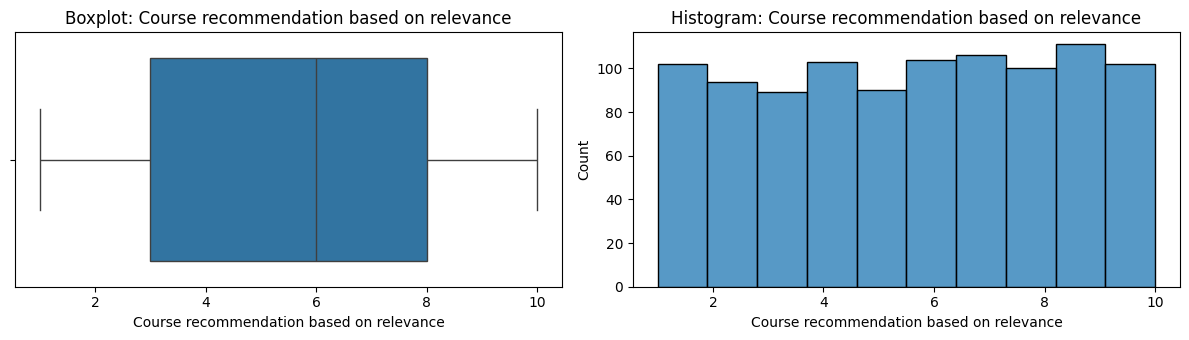

In [22]:
# distribution plots for each rating question (boxplots + histograms)
for c in rating_cols:
    fig, axes = plt.subplots(1,2, figsize=(12,3.5))
    sns.boxplot(x=df[c], ax=axes[0])
    axes[0].set_title(f'Boxplot: {c}')
    sns.histplot(df[c].dropna(), bins=10, kde=False, ax=axes[1])
    axes[1].set_title(f'Histogram: {c}')
    plt.tight_layout()
    plt.show()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
/tmp/ipython-input-3941911692.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_vader', data=comments, order=['positive', 'neutral', 'negative'], palette='viridis')


sentiment_vader
positive    0.7
negative    0.2
neutral     0.1
Name: proportion, dtype: float64


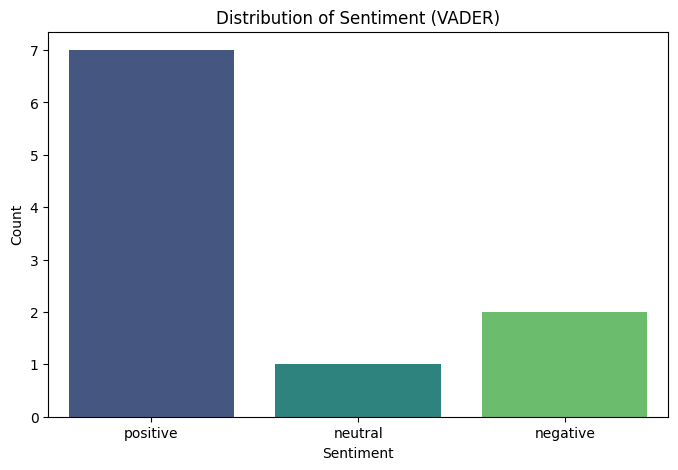

In [23]:
from textblob import TextBlob
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')


comments = pd.read_csv('/content/above sheet can add comments also plz - above sheet can add comments also plz.csv')
text_col = 'Feedback'

# TextBlob polarity
comments['polarity'] = comments[text_col].astype(str).apply(lambda t: TextBlob(t).sentiment.polarity)

# VADER compound score
sid = SentimentIntensityAnalyzer()
comments['vader_compound'] = comments[text_col].astype(str).apply(lambda t: sid.polarity_scores(t)['compound'])

# Classify
comments['sentiment_textblob'] = comments['polarity'].apply(lambda x: 'positive' if x>0.05 else ('negative' if x<-0.05 else 'neutral'))
comments['sentiment_vader'] = comments['vader_compound'].apply(lambda x: 'positive' if x>=0.05 else ('negative' if x<=-0.05 else 'neutral'))

# Quick summary
print(comments['sentiment_vader'].value_counts(normalize=True))

# Plot VADER sentiment distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment_vader', data=comments, order=['positive', 'neutral', 'negative'], palette='viridis')
plt.title('Distribution of Sentiment (VADER)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

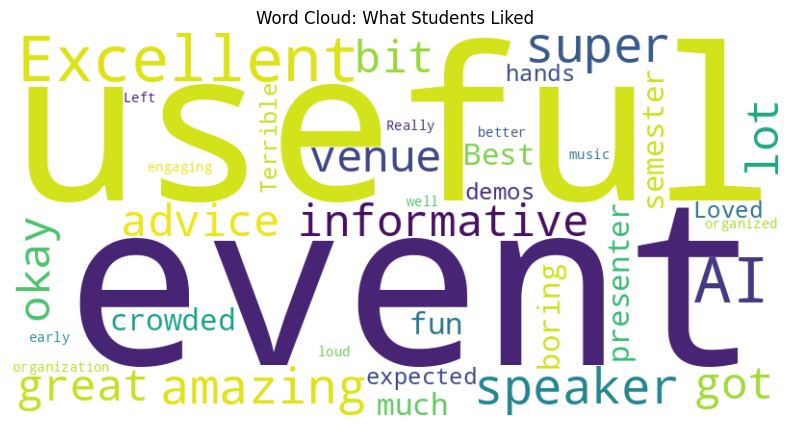

In [25]:
from wordcloud import WordCloud

like_text = ' '.join(comments['Feedback'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(like_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud: What Students Liked")
plt.show()

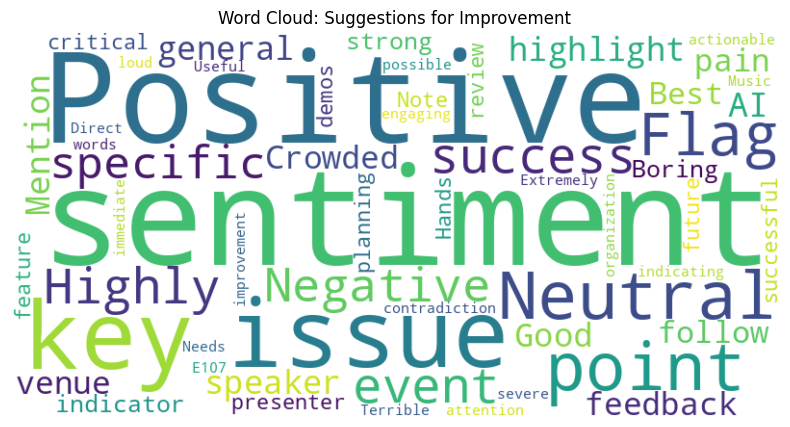

In [27]:
from wordcloud import WordCloud

improve_text = ' '.join(comments['Comments'].dropna())
improve_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(improve_text)
plt.figure(figsize=(10, 5))
plt.imshow(improve_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud: Suggestions for Improvement")
plt.show()

In [29]:
#  Summary Stats
print("\nSentiment Counts:")
print(comments['sentiment_vader'].value_counts())


Sentiment Counts:
sentiment_vader
positive    7
negative    2
neutral     1
Name: count, dtype: int64


In [31]:
#Average rating
print("\nAverage Rating (Well versed with the subject):")
print(df['Well versed with the subject'].mean())


Average Rating (Well versed with the subject):
7.497502497502498


In [33]:
print("\nTop Suggestions for Improvement:")
print(comments['Comments'].head())


Top Suggestions for Improvement:
0    Positive sentiment. Mention of "AI speaker" is...
1          Positive sentiment. Good, general feedback.
2    Neutral sentiment. "Crowded venue" is a key pa...
3    Highly positive. "Best event" is a strong indi...
4    Negative sentiment. "Boring presenter" is a cr...
Name: Comments, dtype: object
